# EEG Motor Imagery BCI — Exploratory Data Analysis (EDA)

This notebook focuses on the raw data structures, metadata, annotation event triggers, and signal statistics of the PhysioNet EEG Motor Movement/Imagery dataset.


In [29]:
import mne
import numpy as np
import matplotlib.pyplot as plt


## 1. Load Raw EEG Dataset
We load subject 1, runs 3 and 4 using MNE-Python and check raw properties.


In [30]:
subject = 1
runs = [3, 4]

# Load EDF files
edf_files = mne.datasets.eegbci.load_data(subject, runs, verbose='WARNING')
raws = [mne.io.read_raw_edf(f, preload=True, verbose='WARNING') for f in edf_files]
raw = mne.concatenate_raws(raws)

# Standardize coordinates and set montage
mne.datasets.eegbci.standardize(raw)
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage)


<RawEDF | S001R03.edf, 64 x 40000 (250.0 s), ~19.6 MiB, data loaded>

## 2. Inspecting Dataset Metadata
Let's print the basic info of the raw EEG signals, including channel names, sampling rate, and recording length.


In [42]:
print("Info details:")
print(f"Sampling Frequency: {raw.info['sfreq']} Hz")
print(f"Number of channels: {len(raw.ch_names)}")
print(f"Channels list: {raw.ch_names[:10]} ...")
print(f"Recording duration: {raw.times[-1]:.2f} seconds")

Info details:
Sampling Frequency: 160.0 Hz
Number of channels: 64
Channels list: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1'] ...
Recording duration: 249.99 seconds


## 3. Event Annotations and Trial Distribution
We extract the annotations from the raw EEG recording and analyze the timing and balance of different trials (`T0` = Rest, `T1` = Left Hand, `T2` = Right Hand).


In [32]:
events, event_id = mne.events_from_annotations(raw, verbose='WARNING')
print("Event ID mapping:", event_id)
print(f"Total events: {len(events)}")

# Count event occurrences
for label, code in event_id.items():
    count = np.sum(events[:, 2] == code)
    print(f"  Event '{label}' (code {code}): {count} occurrences")


Event ID mapping: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}
Total events: 60
  Event 'T0' (code 1): 30 occurrences
  Event 'T1' (code 2): 16 occurrences
  Event 'T2' (code 3): 14 occurrences


### 3.1 Event Count Distribution Plot
We plot a bar chart showing the distribution of trial counts per class to verify class balance.


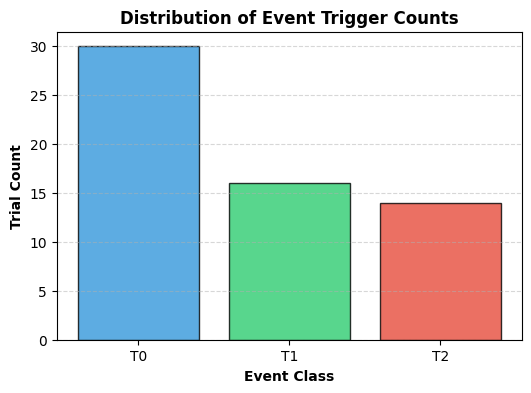

In [33]:
# Plot bar chart of event counts
labels = list(event_id.keys())
counts = [np.sum(events[:, 2] == event_id[k]) for k in labels]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
plt.xlabel('Event Class', fontweight='bold')
plt.ylabel('Trial Count', fontweight='bold')
plt.title('Distribution of Event Trigger Counts', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


### 3.2 Event Timeline Overlaid on All 64 Channels (8x8 Grid Layout)
To visualize how raw EEG data correlates with tasks over time across the entire scalp, we plot the signal traces for **all 64 channels** organized in an **$8 \times 8$ grid layout** over the first 60 seconds. Each channel plot is overlaid with the event boundaries:
- **Grey Shaded (`T0`)**: Rest period.
- **Green Shaded (`T1`)**: Imagined Left Hand movement.
- **Red Shaded (`T2`)**: Imagined Right Hand movement.

*Note: Shaded regions are drawn with transparency and without text labels to maintain clarity and prevent text crowding across the 64 subplots.*


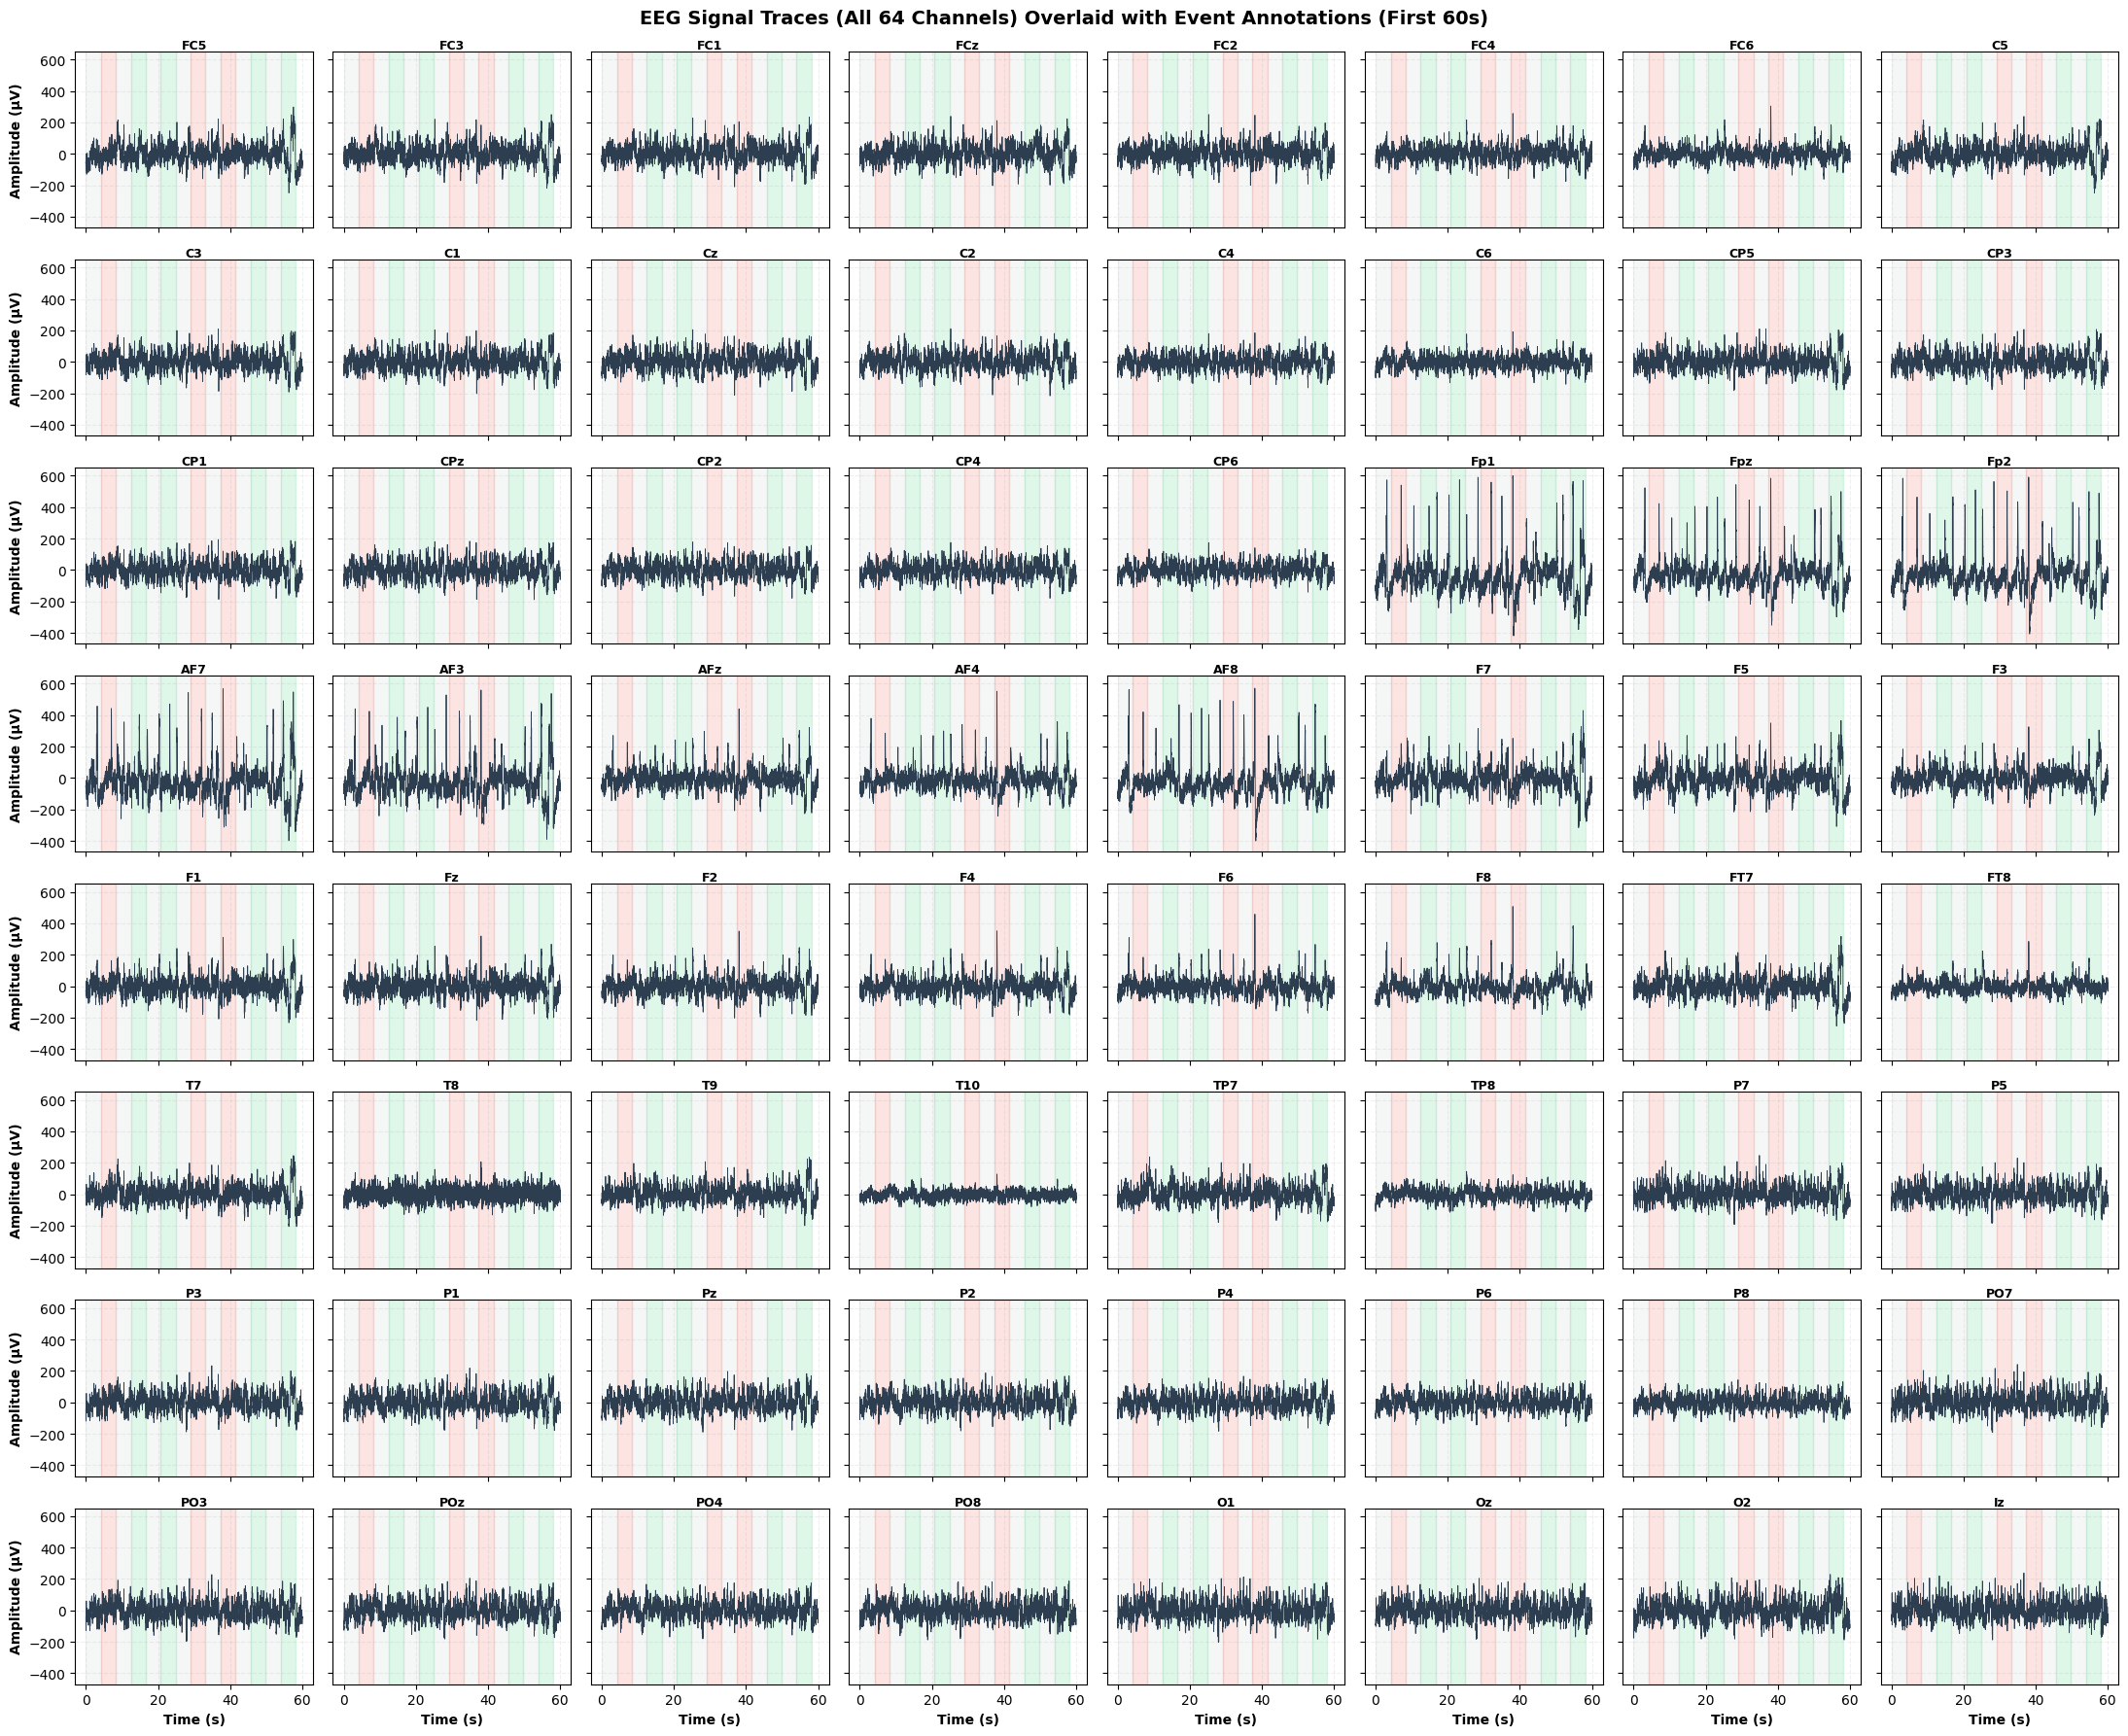

In [34]:
# Select window (0 to 60 seconds)
crop_window = (0.0, 60.0)
raw_crop = raw.copy().crop(*crop_window)
times = raw_crop.times

# Create 8 rows x 8 columns of subplots sharing both axes
fig, axes = plt.subplots(8, 8, figsize=(22, 18), sharex=True, sharey=True)
axes_flat = axes.flatten()

# Define colors for events
colors = {'T0': '#bdc3c7', 'T1': '#2ecc71', 'T2': '#e74c3c'}

# Plot each channel
for idx, ch_name in enumerate(raw.ch_names[:64]):
    ax = axes_flat[idx]
    data_ch = raw_crop.get_data(picks=[ch_name])[0] * 1e6  # scale to μV
    
    # Plot signal trace
    ax.plot(times, data_ch, color='#2c3e50', linewidth=0.6)
    
    # Shade annotation regions
    for ann in raw.annotations:
        onset = ann['onset']
        duration = ann['duration']
        description = ann['description']
        
        # Check if annotation overlaps with our plotted window
        if onset >= crop_window[0] and onset + duration <= crop_window[1]:
            ax.axvspan(onset, onset + duration, color=colors.get(description, '#f1c40f'), alpha=0.15)
            
    ax.set_title(ch_name, fontsize=9, fontweight='bold', pad=2)
    ax.grid(True, linestyle='--', alpha=0.2)
    
# Set global labels
for i in range(8):
    axes[7, i].set_xlabel('Time (s)', fontsize=10, fontweight='bold')
    axes[i, 0].set_ylabel('Amplitude (μV)', fontsize=10, fontweight='bold')

fig.suptitle(f"EEG Signal Traces (All 64 Channels) Overlaid with Event Annotations (First 60s)", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


## 4. Signal Amplitude Statistics
Let's extract raw amplitude values and check basic statistics across the channels to assess noise levels and identify potential bad channels.


In [35]:
# Extract all data (shape: n_channels, n_samples)
data = raw.get_data()

print(f"Global max amplitude: {np.max(np.abs(data)) * 1e6:.2f} μV")
print(f"Global mean amplitude: {np.mean(data) * 1e6:.2f} μV")
print(f"Global standard deviation: {np.std(data) * 1e6:.2f} μV")

# Check channel-specific variance
var_per_channel = np.var(data, axis=-1)
sorted_var_indices = np.argsort(var_per_channel)[::-1]

print("\nChannels with highest variance (possible noise/artifacts):")
for idx in sorted_var_indices[:5]:
    print(f"  Channel {raw.ch_names[idx]}: {var_per_channel[idx] * 1e12:.2f} μV^2")


Global max amplitude: 600.00 μV
Global mean amplitude: -2.70 μV
Global standard deviation: 58.12 μV

Channels with highest variance (possible noise/artifacts):
  Channel Fp1: 11179.18 μV^2
  Channel Fp2: 9505.85 μV^2
  Channel AF7: 9290.49 μV^2
  Channel AF3: 8759.08 μV^2
  Channel Fpz: 8021.99 μV^2


### 4.1 Amplitude Boxplot across Scalp Regions
We display a boxplot of signal amplitudes across 10 representative channels spanning the frontal, central, parietal, and occipital regions to visually inspect outliers and verify DC baseline offsets.


/var/folders/p6/nxbwc7ts5_3_4ml7gv835g5w0000gn/T/ipykernel_93195/1579540520.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_subset.T, labels=[raw.ch_names[p] for p in picks], patch_artist=True,


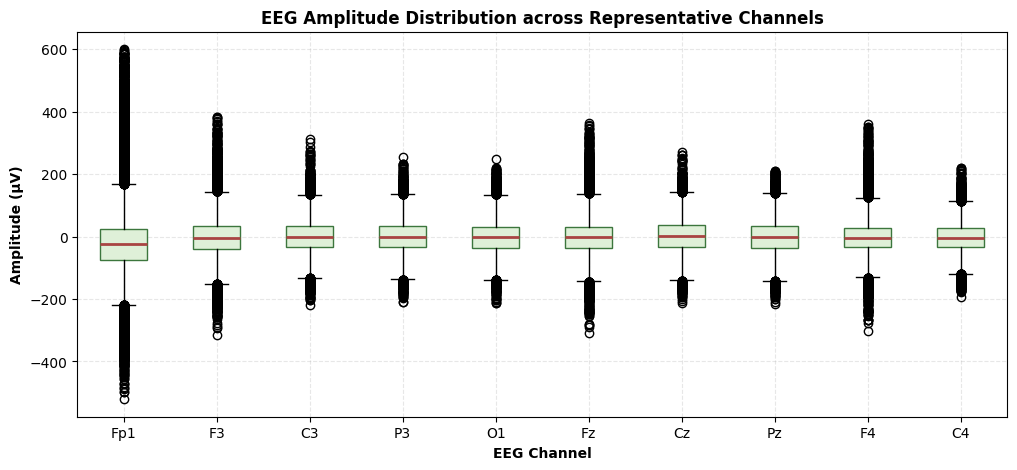

In [36]:
# Select channels from different scalp regions
ch_subset = ['Fp1', 'F3', 'C3', 'P3', 'O1', 'Fz', 'Cz', 'Pz', 'F4', 'C4']
picks = [raw.ch_names.index(ch) for ch in ch_subset if ch in raw.ch_names]
data_subset = data[picks] * 1e6  # scale to uV

plt.figure(figsize=(12, 5))
plt.boxplot(data_subset.T, labels=[raw.ch_names[p] for p in picks], patch_artist=True,
            boxprops=dict(facecolor='#dff0d8', color='#3c763d'),
            medianprops=dict(color='#a94442', linewidth=2))
plt.ylabel('Amplitude (μV)', fontweight='bold')
plt.xlabel('EEG Channel', fontweight='bold')
plt.title('EEG Amplitude Distribution across Representative Channels', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


### 4.2 Signal Histograms (Central Motor Channels)
We plot the histograms of amplitude values for the motor cortex channels C3, Cz, and C4. Since clean brain activity is approximately Gaussian-distributed, checking this distribution helps identify amplifier saturation or high-amplitude spikes.


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


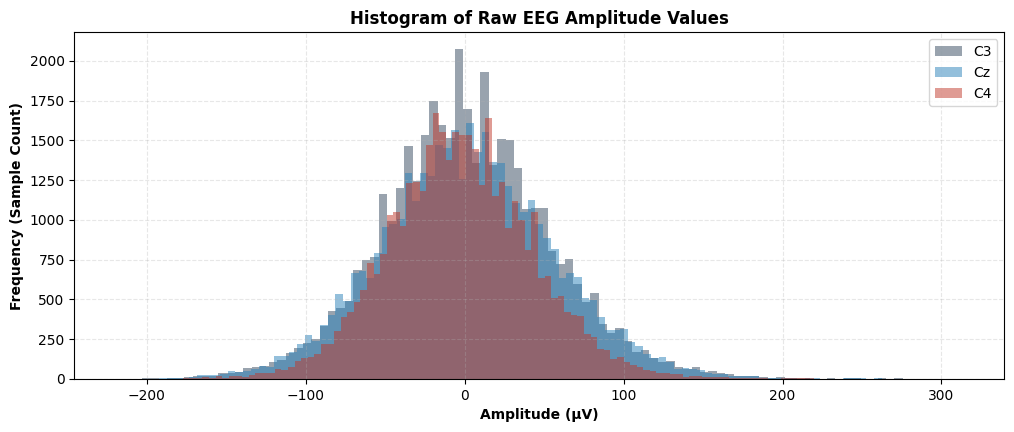

In [ ]:
target_chs = ['C3', 'Cz', 'C4']
colors = ['#34495e', '#2980b9', '#c0392b']

plt.figure(figsize=(12, 4.5))
for idx, ch in enumerate(target_chs):
    if ch in raw.ch_names:
        ch_data = raw.copy().pick([ch]).get_data()[0] * 1e6  # scale to uV
        plt.hist(ch_data, bins=100, alpha=0.5, label=ch, color=colors[idx])

plt.xlabel('Amplitude (μV)', fontweight='bold')
plt.ylabel('Frequency (Sample Count)', fontweight='bold')
plt.title('Histogram of Raw EEG Amplitude Values', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()
